# Trader Behavior vs Market Sentiment (Fear & Greed Index)

**Objective:** Explore the relationship between trader performance (from historical trade data) and overall market sentiment, as measured by the Bitcoin Fear & Greed Index, in order to uncover patterns that could inform smarter trading strategies.

**Datasets used:**
- `historical_data.csv` — individual trade-level execution data (account, coin, side, size, PnL, fees, timestamps)
- `fear_greed_index.csv` — daily Bitcoin market sentiment score and classification (Extreme Fear → Extreme Greed)

**Author:** Pranav Mahadev Raikar


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)


## 1. Load the Data

In [2]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print("Trades shape:", trades.shape)
print("Fear & Greed shape:", fg.shape)
trades.head()


Trades shape: (211224, 16)
Fear & Greed shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 2. Data Cleaning & Merging

Trade timestamps are parsed to dates so each trade can be joined with that day's sentiment reading. `Direction` is also simplified into a `pos_type` column (`Long` / `Short` / `Other`) to study directional behavior.

In [4]:
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['datetime'].dt.date

fg['date'] = pd.to_datetime(fg['date']).dt.date

merged = trades.merge(fg[['date', 'value', 'classification']], on='date', how='left')

print(f"Rows without a matching sentiment reading: {merged['classification'].isna().sum()} / {len(merged)}")
merged = merged.dropna(subset=['classification'])

def simplify_direction(d):
    if 'Long' in d:
        return 'Long'
    elif 'Short' in d:
        return 'Short'
    else:
        return 'Other'

merged['pos_type'] = merged['Direction'].apply(simplify_direction)

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories=SENTIMENT_ORDER, ordered=True)

merged[['date','Account','Coin','Side','Direction','pos_type','Size USD','Closed PnL','value','classification']].head()


Rows without a matching sentiment reading: 6 / 211224


,date,Account,Coin,Side,Direction,pos_type,Size USD,Closed PnL,value,classification
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,Other,7872.16,0.0,80.0,Extreme Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,Other,127.68,0.0,80.0,Extreme Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,Other,1150.63,0.0,80.0,Extreme Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,Other,1142.04,0.0,80.0,Extreme Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,BUY,Buy,Other,69.75,0.0,80.0,Extreme Greed


## 3. Exploratory Overview

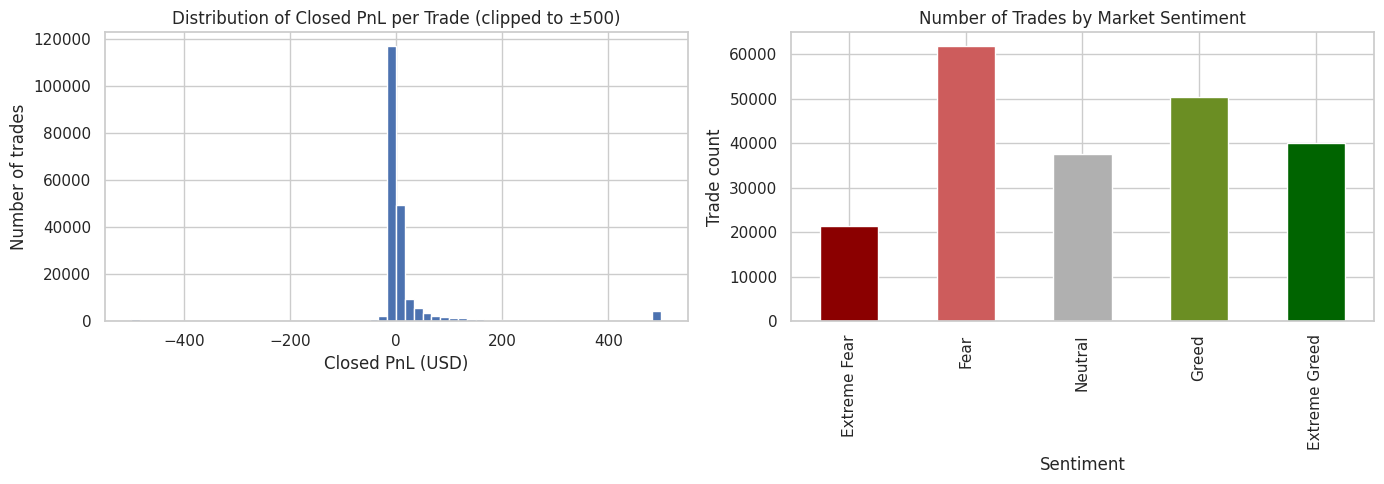

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merged['Closed PnL'].clip(-500, 500), bins=60, color='#4C72B0')
axes[0].set_title('Distribution of Closed PnL per Trade (clipped to ±500)')
axes[0].set_xlabel('Closed PnL (USD)')
axes[0].set_ylabel('Number of trades')

merged['classification'].value_counts().reindex(SENTIMENT_ORDER).plot(
    kind='bar', ax=axes[1], color=['#8B0000','#CD5C5C','#B0B0B0','#6B8E23','#006400']
)
axes[1].set_title('Number of Trades by Market Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Trade count')
plt.tight_layout()
plt.show()


**Observation:** PnL per trade is heavily concentrated near zero (most trades are small or breakeven), with a long tail of larger wins/losses. The number of trades is also unevenly distributed across sentiment regimes — this is normalized for later using daily averages rather than raw totals.

## 4. Daily Aggregation

To fairly compare across sentiment regimes (which have different numbers of days), trades are aggregated to a **daily** level: total PnL, total volume, trade count, and win rate for each day, tagged with that day's sentiment classification.

In [6]:
daily = merged.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_volume=('Size USD', 'sum'),
    n_trades=('Closed PnL', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    classification=('classification', 'first'),
    sentiment_value=('value', 'first')
).reset_index()

win_rate = (merged[merged['Closed PnL'] != 0]
            .groupby('date')['Closed PnL']
            .apply(lambda s: (s > 0).mean())
            .rename('win_rate'))

daily = daily.merge(win_rate, on='date', how='left')
daily['classification'] = pd.Categorical(daily['classification'], categories=SENTIMENT_ORDER, ordered=True)

print(f"Total days covered: {len(daily)}")
daily.groupby('classification', observed=True).size().reindex(SENTIMENT_ORDER)


Total days covered: 479


classification
Extreme Fear      14
Fear              91
Neutral           67
Greed            193
Extreme Greed    114
dtype: int64

## 5. Trader Performance by Sentiment Regime

In [7]:
sent_summary = daily.groupby('classification', observed=True).agg(
    avg_daily_pnl=('total_pnl', 'mean'),
    median_daily_pnl=('total_pnl', 'median'),
    avg_daily_volume=('total_volume', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades_per_day=('n_trades', 'mean')
).reindex(SENTIMENT_ORDER)

sent_summary


,avg_daily_pnl,median_daily_pnl,avg_daily_volume,avg_win_rate,avg_trades_per_day
classification,,,,,
Extreme Fear,52793.589178,22561.739636,8.177447e+06,0.654433,1528.571429
Fear,36891.818040,1412.314654,5.311261e+06,0.880714,679.527473
Neutral,19297.323516,1818.573295,2.690180e+06,0.793790,562.477612
Greed,11140.566181,678.475928,1.495246e+06,0.813021,260.637306
Extreme Greed,23817.292199,3127.536297,1.091800e+06,0.886533,350.807018


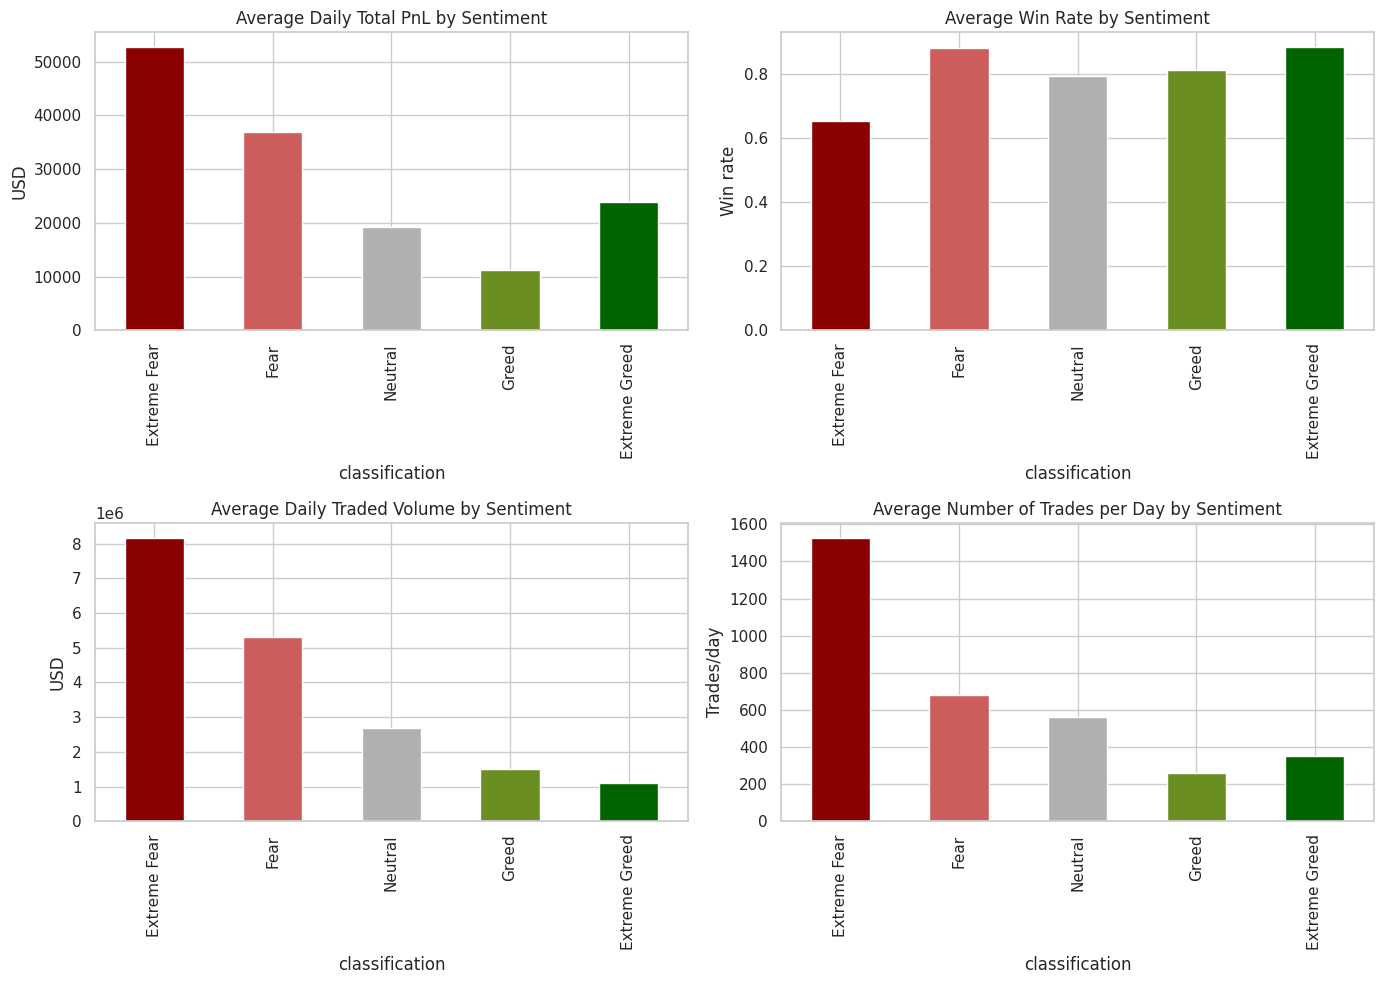

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#8B0000','#CD5C5C','#B0B0B0','#6B8E23','#006400']

sent_summary['avg_daily_pnl'].plot(kind='bar', ax=axes[0,0], color=colors)
axes[0,0].set_title('Average Daily Total PnL by Sentiment')
axes[0,0].set_ylabel('USD')
axes[0,0].axhline(0, color='black', linewidth=0.8)

sent_summary['avg_win_rate'].plot(kind='bar', ax=axes[0,1], color=colors)
axes[0,1].set_title('Average Win Rate by Sentiment')
axes[0,1].set_ylabel('Win rate')

sent_summary['avg_daily_volume'].plot(kind='bar', ax=axes[1,0], color=colors)
axes[1,0].set_title('Average Daily Traded Volume by Sentiment')
axes[1,0].set_ylabel('USD')

sent_summary['avg_trades_per_day'].plot(kind='bar', ax=axes[1,1], color=colors)
axes[1,1].set_title('Average Number of Trades per Day by Sentiment')
axes[1,1].set_ylabel('Trades/day')

plt.tight_layout()
plt.show()


**Observation:** Both average daily PnL and trading activity (volume, trade count) are highest during **Extreme Fear**, and decline steadily as sentiment moves toward **Greed**, with a partial rebound in **Extreme Greed**. This suggests this trader cohort tends to be most active — and most profitable, on average — when the broader market is fearful, consistent with a **contrarian / "buy the dip"** style of trading rather than momentum-chasing.

## 6. Long vs Short Positioning by Sentiment

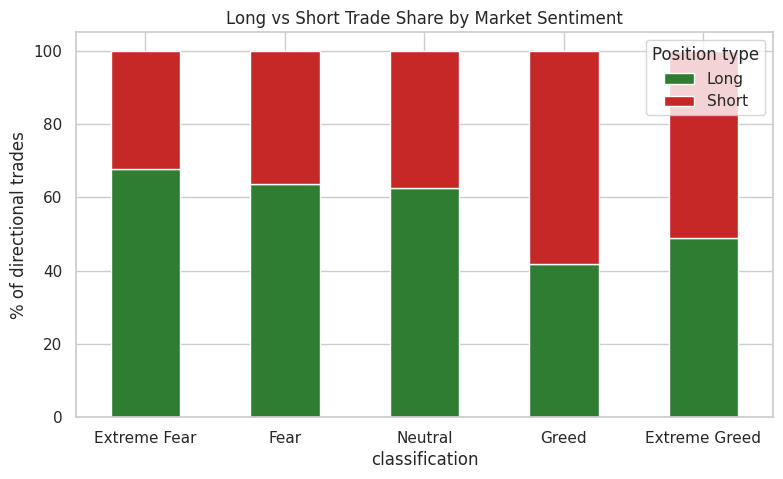

pos_type,Long,Short
classification,,
Extreme Fear,67.817680,32.182320
Fear,63.588295,36.411705
Neutral,62.388658,37.611342
Greed,41.905075,58.094925
Extreme Greed,48.814344,51.185656


In [9]:
directional = merged[merged['pos_type'].isin(['Long', 'Short'])]
ls_counts = directional.groupby(['classification', 'pos_type'], observed=True).size().unstack(fill_value=0)
ls_pct = ls_counts.div(ls_counts.sum(axis=1), axis=0) * 100
ls_pct = ls_pct.reindex(SENTIMENT_ORDER)

ls_pct.plot(kind='bar', stacked=True, figsize=(9,5), color=['#2E7D32','#C62828'])
plt.title('Long vs Short Trade Share by Market Sentiment')
plt.ylabel('% of directional trades')
plt.legend(title='Position type')
plt.xticks(rotation=0)
plt.show()

ls_pct


**Observation:** Long positions dominate during Fear and Extreme Fear (roughly two-thirds of directional trades), while Short positions become more common as sentiment shifts to Greed. This reinforces the contrarian pattern: traders lean long when the market is fearful (buying weakness) and lean more short-oriented as euphoria builds.

## 7. Correlation Between Sentiment Score and Performance

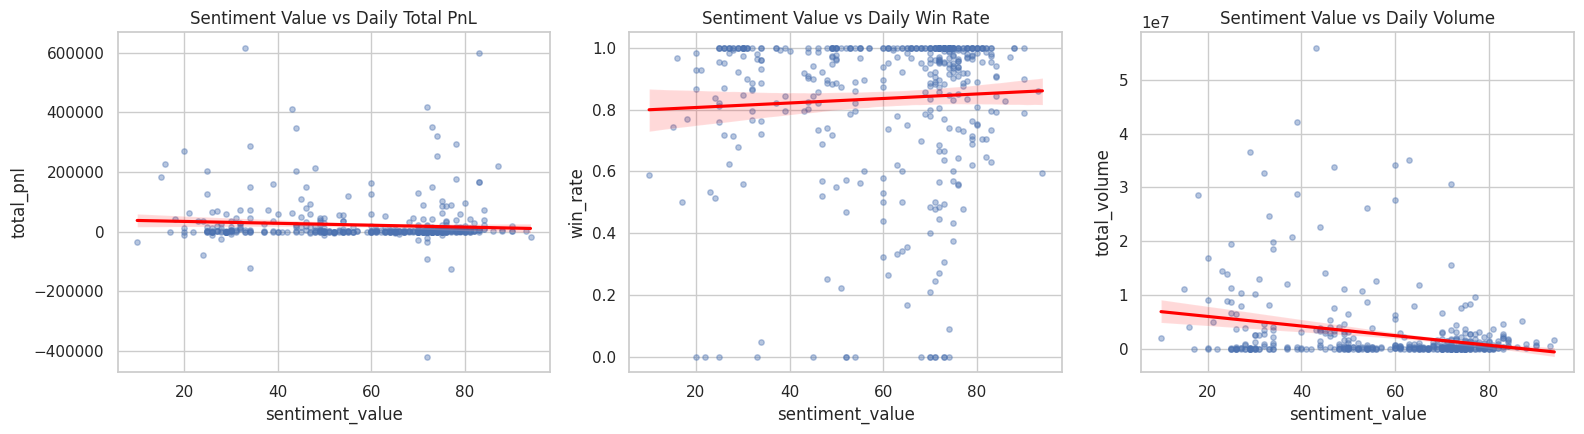

,correlation with sentiment_value
total_pnl,-0.082642
win_rate,0.055399
total_volume,-0.264371


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.regplot(data=daily, x='sentiment_value', y='total_pnl', ax=axes[0],
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
axes[0].set_title('Sentiment Value vs Daily Total PnL')

sns.regplot(data=daily, x='sentiment_value', y='win_rate', ax=axes[1],
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
axes[1].set_title('Sentiment Value vs Daily Win Rate')

sns.regplot(data=daily, x='sentiment_value', y='total_volume', ax=axes[2],
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
axes[2].set_title('Sentiment Value vs Daily Volume')

plt.tight_layout()
plt.show()

corr_table = daily[['sentiment_value','total_pnl','win_rate','total_volume']].corr()['sentiment_value'].drop('sentiment_value')
corr_table.to_frame('correlation with sentiment_value')


**Observation:** The correlation between the raw sentiment value (0–100 fear/greed score) and daily PnL/volume is negative — as the market becomes greedier, this cohort's daily profit and trading volume tend to *decrease*. The correlation with win rate is weak, suggesting sentiment affects *how much/how often* they trade more than their per-trade accuracy.

## 8. Top Traders and Their Sentiment Sensitivity

In [11]:
top_accounts = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(5)
print("Top 5 accounts by total PnL:")
top_accounts


Top 5 accounts by total PnL:


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
Name: Closed PnL, dtype: float64

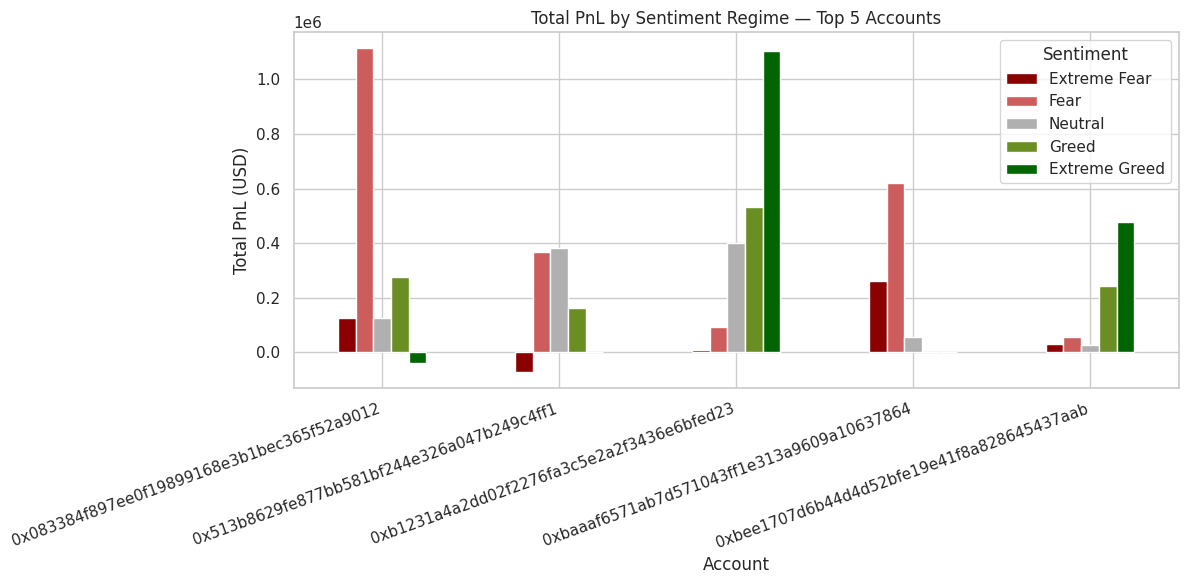

classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,124769.221441,1.113374e+06,125650.116740,276719.270187,-4.028234e+04
0x513b8629fe877bb581bf244e326a047b249c4ff1,-71121.820704,3.671662e+05,381330.494050,163047.664946,0.000000e+00
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9544.906134,9.316516e+04,401309.434693,534058.236330,1.105305e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,261917.977792,6.208724e+05,57368.780126,4.672458,0.000000e+00
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,30774.092128,5.597880e+04,27116.682664,243399.513140,4.788115e+05


In [12]:
top5_ids = top_accounts.index.tolist()
top5_detail = merged[merged['Account'].isin(top5_ids)].groupby(
    ['Account', 'classification'], observed=True
)['Closed PnL'].sum().unstack(fill_value=0).reindex(columns=SENTIMENT_ORDER)

top5_detail.plot(kind='bar', figsize=(12,6), color=['#8B0000','#CD5C5C','#B0B0B0','#6B8E23','#006400'])
plt.title('Total PnL by Sentiment Regime — Top 5 Accounts')
plt.ylabel('Total PnL (USD)')
plt.xlabel('Account')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

top5_detail


**Observation:** The top-performing accounts generate a large share of their profit during Fear/Extreme Fear periods, reinforcing that the most successful traders in this dataset lean into market fear rather than avoiding it.

## 9. Key Insights Summary

1. **Contrarian edge:** Both aggregate and top-trader PnL peak during **Extreme Fear**, and decline through Fear → Neutral → Greed, with a partial rebound in Extreme Greed. This dataset's traders appear to profit most by leaning against the crowd rather than with it.
2. **Activity follows fear:** Trading volume and trade count are also highest in Extreme Fear — this cohort trades more aggressively when the market is scared, not less.
3. **Directional bias tracks sentiment:** Long positions dominate in Fear/Extreme Fear; Short positions become relatively more common as sentiment turns to Greed — consistent with "buying the dip, fading the euphoria."
4. **Sentiment score correlates negatively with PnL and volume:** Higher (greedier) sentiment scores are mildly but consistently associated with lower daily profit and lower trading activity for this cohort.
5. **Win rate is fairly sentiment-agnostic:** The accuracy of individual trades doesn't shift much with sentiment — the edge comes from *sizing/timing* activity around fear, not from picking better trades during any particular regime.

**Caveats:** This is a single, relatively small cohort of ~32 accounts, so results may reflect the strategy of a few dominant traders rather than a universal market effect. Extreme Fear days are also fewer in number (14 days) than other regimes, so those averages carry more noise/variance.
